In [22]:
# --- parameters (patch_notebook_params.py) ---
MAX_EPOCHS = 2000
N_SAMPLES = 10           # run_metrics.py forces 50 for generative methods
RESET_TRAINING = True
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "results/metrics.csv"


In [23]:
# --- epoch heartbeat (patch_notebook_params.py) ---
import pytorch_lightning as _pl

class EpochHeartbeat(_pl.Callback):
    """Prints one clear progress line every `every_n_epochs` epochs, so
    sbatch logs show training progress without the noise of a per-batch
    tqdm progress bar (which doesn't render well once redirected to a
    plain log file).    """

    def __init__(self, every_n_epochs: int = 1):
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0 and epoch != trainer.max_epochs:
            return
        parts = []
        for k, v in sorted(trainer.callback_metrics.items()):
            try:
                parts.append(f'{k}={float(v):.4f}')
            except (TypeError, ValueError):
                pass
        print(f'[progress] epoch {epoch}/{trainer.max_epochs} | ' + ' | '.join(parts), flush=True)


## Consistency Model — Sea Ice Concentration (SIC)

In [24]:
!nvidia-smi

Sat Jul 25 14:14:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.158.01             Driver Version: 570.158.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:4C:00.0 Off |                    0 |
| N/A   57C    P0            130W /  400W |   14979MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [25]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

In [26]:
import json
import math
import os
import zipfile
import glob
import importlib
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../..')     # -> consistency/  (consistency_models, spectral_utils)
sys.path.append('../../..')  # -> 4dvarnet-starter-devs/

import consistency_models.utils
import consistency_models.consistency_models_CM
importlib.reload(consistency_models.utils)
importlib.reload(consistency_models.consistency_models_CM)

from consistency_models.consistency_models_CM import (
    ConsistencySamplingAndEditingFewSteps_TimeEmbedding,
    ConsistencyTrainingFewSteps_TimeEmbedding,
    ema_decay_rate_schedule,
)
from consistency_models.utils import update_ema_model_, pseudo_huber_loss

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("properscoring not installed -- CRPS disabled.")

## DataModule -- SIC (ASIP / OSISAF)

C=9, H=240, W=240
Train: 300, Val: 50, Test: 43
asip: (9, 240, 240)  input: (9, 240, 240)  osisaf: (9, 240, 240)
asip range: [0.000, 1.000]
asip std: 0.4139
NaN fraction in asip: 22.2%


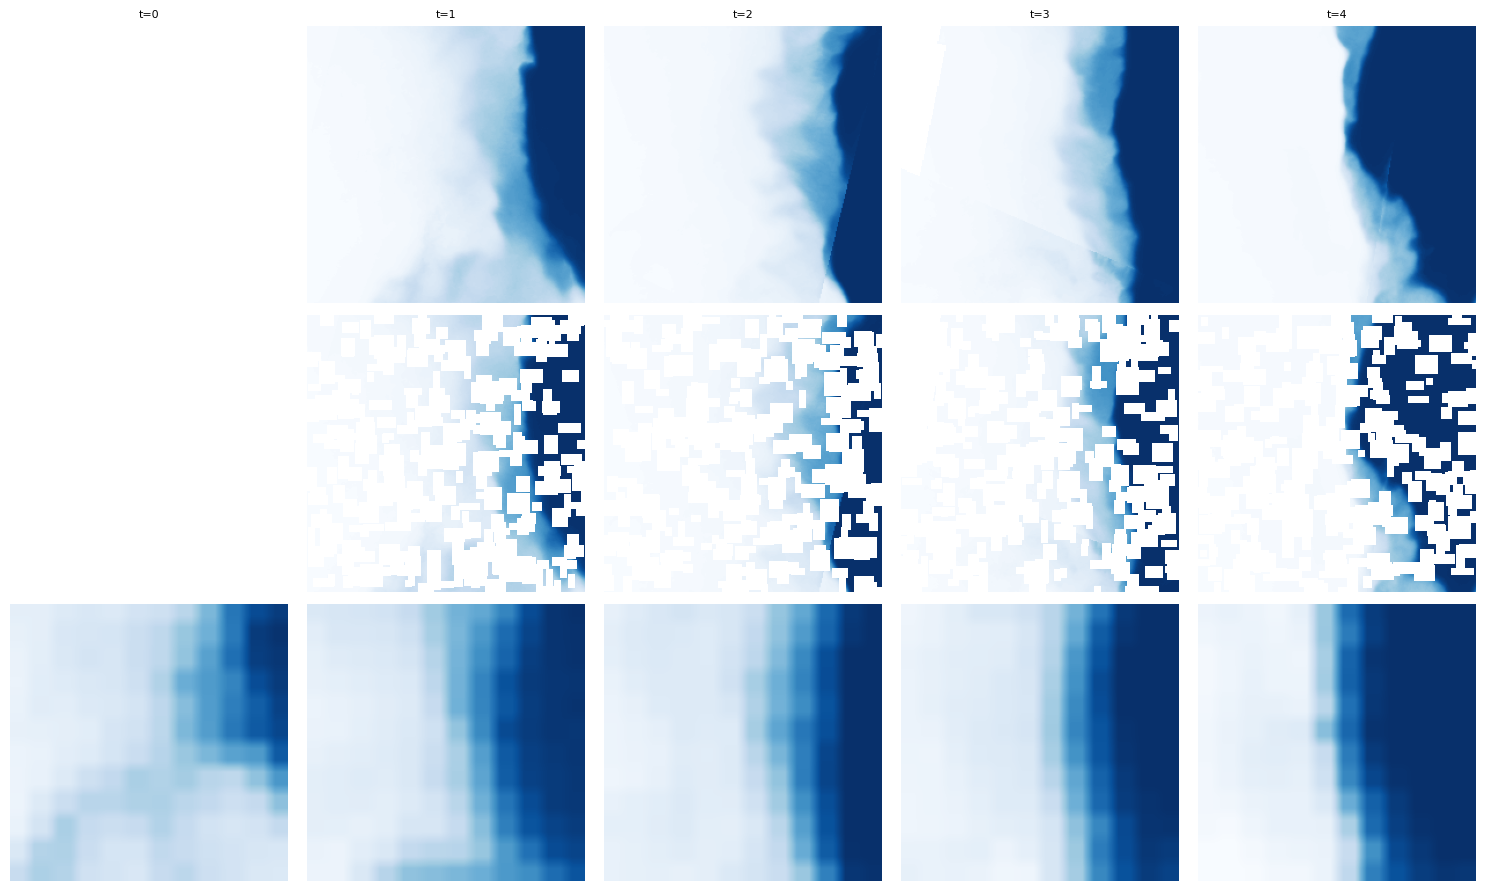

In [27]:
sys.path.insert(0, '../../..')
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

import functools as ft
from contrib.ASIP_OSISAF.data_simple import BaseDataModule, TrainingItem_4da

T_CROP = 9

class CroppedDataModule(BaseDataModule):
    def __init__(self, *args, t_crop=9, **kwargs):
        super().__init__(*args, **kwargs)
        self.t_crop = t_crop

    def build_batch(self):
        # ASIP/input/osisaf are already in [0, 1] in the NetCDF file — no rescaling needed
        return ft.partial(ft.reduce, lambda i, f: f(i), [
            TrainingItem_4da._make,
        ])

    def setup(self, stage='test'):
        super().setup(stage)
        for ds in [self.train_ds, self.val_ds, self.test_ds]:
            ds.db = ds.db.isel(time=slice(-self.t_crop, None))

datamodule = CroppedDataModule(
    asip_paths="../../../data/asip_database_daw15_sparse.nc",
    split_train=slice(0, 300),
    split_val=slice(300, 350),
    split_test=slice(350, 393),
    da=True,
    norm_stats=[0, 1],
    norm_stats_covs=[
        {'t2m': 270.08, 'istl1': 267.68, 'siconc': 0, 'sst': 276.97, 'skt': 270.50},
        {'t2m': 14.67,  'istl1': 7.80,  'siconc': 1, 'sst': 6.82,   'skt': 15.21},
    ],
    t_crop=T_CROP,
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = sample.asip.shape[0]
H, W = sample.asip.shape[1], sample.asip.shape[2]
print(f"C={C}, H={H}, W={W}")
print(f"Train: {len(datamodule.train_ds)}, Val: {len(datamodule.val_ds)}, Test: {len(datamodule.test_ds)}")
print(f"asip: {sample.asip.shape}  input: {sample.input.shape}  osisaf: {sample.osisaf.shape}")
print(f"asip range: [{np.nanmin(sample.asip):.3f}, {np.nanmax(sample.asip):.3f}]")
print(f"asip std: {np.nanstd(sample.asip):.4f}")
print(f"NaN fraction in asip: {np.isnan(sample.asip).mean()*100:.1f}%")

fig, axes = plt.subplots(3, min(C, 5), figsize=(3 * min(C, 5), 9))
for t_idx in range(min(C, 5)):
    axes[0, t_idx].imshow(sample.asip[t_idx], vmin=0, vmax=1, cmap='Blues_r')
    axes[0, t_idx].set_title(f't={t_idx}', fontsize=8); axes[0, t_idx].axis('off')
    axes[1, t_idx].imshow(sample.input[t_idx], vmin=0, vmax=1, cmap='Blues_r')
    axes[1, t_idx].axis('off')
    axes[2, t_idx].imshow(sample.osisaf[t_idx], vmin=0, vmax=1, cmap='Blues_r')
    axes[2, t_idx].axis('off')
axes[0, 0].set_ylabel('ASIP (target)', fontsize=10)
axes[1, 0].set_ylabel('Input (gappy)', fontsize=10)
axes[2, 0].set_ylabel('OSISAF (cond.)', fontsize=10)
plt.tight_layout()
plt.show()

### UNet Building Blocks

In [28]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.time_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(time_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.time_level_projection(time_level)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, time_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, time_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class TimeLevelEmbedding(nn.Module):
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()
        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)
        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)
        return self.projection(h)


def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    padding = (0, pad_w, 0, pad_h)
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]

### UNet (Consistency Model)

In [29]:
@dataclass
class UNetConfig:
    channels: int = 9
    cond_channels: Optional[int] = None       # conditioning channels (default = channels)
    time_level_channels: int = 128
    time_level_scale: float = 16.0
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (64, 64)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


class UNet(nn.Module):
    def __init__(self, config: UNetConfig) -> None:
        super().__init__()
        self.config = config

        cc = config.cond_channels if config.cond_channels is not None else config.channels
        # input = cat(x_noisy[C], y_filled[cc], mask[cc]) → C + 2*cc
        self.input_projection = nn.Conv2d(
            config.channels + 2 * cc,
            config.top_blocks_channels[0],
            kernel_size=3, padding="same",
        )
        self.time_level_embedding = TimeLevelEmbedding(
            config.time_level_channels, config.time_level_scale
        )

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.output_projection = nn.Conv2d(
            config.top_blocks_channels[0], config.channels, kernel_size=3, padding="same"
        )

    def forward(self, x: Tensor, y: Tensor, time: Tensor, time_prime: Tensor) -> Tensor:
        mask = (~torch.isnan(y)).to(x.dtype)        # (B, cc, H, W) — full mask on all of y
        y_filled = torch.nan_to_num(y, nan=0.0)
        inp = torch.cat((x, y_filled, mask), dim=1) # (B, C + 2*cc, H, W)
        inp, padding = _pad_to_multiple(inp, multiple=8)

        h = self.input_projection(inp)

        emb1 = self.time_level_embedding(time)
        emb2 = self.time_level_embedding(time_prime)
        time_level = torch.cat([emb1, emb2], dim=1)

        top_encoder_embeddings = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, time_level)
                top_encoder_embeddings.append(h)
            else:
                h = block(h)

        mid_encoder_embeddings = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, time_level)
                mid_encoder_embeddings.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        out = self.output_projection(h)
        return _unpad(out, padding)

    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx]))
                ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx]))
                oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, 2 * self.config.time_level_channels, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(
            ic, oc, 2 * self.config.time_level_channels, self.config.n_heads, dropout
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "UNet":
        with open(os.path.join(pretrained_path, "config.json"), mode="r") as f:
            config_dict = json.load(f)
        model = cls(UNetConfig(**config_dict))
        model.load_state_dict(
            torch.load(os.path.join(pretrained_path, "model.pt"), map_location="cpu")
        )
        return model


C = datamodule.train_ds[0].asip.shape[0]
summary(
    UNet(UNetConfig(channels=C, cond_channels=2*C)),
    input_size=(
        (1, C, H, W),      # x_noisy
        (1, 2*C, H, W),    # y = cat(input, osisaf)
        (1,),               # time
        (1,),               # time_prime
    ),
)

Layer (type:depth-idx)                        Output Shape              Param #
UNet                                          [1, 9, 240, 240]          --
├─Conv2d: 1-1                                 [1, 64, 240, 240]         25,984
├─TimeLevelEmbedding: 1-2                     [1, 128, 1, 1]            64
│    └─Sequential: 2-1                        [1, 128, 1, 1]            --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
│    │    └─Rearrange: 3-4                    [1, 128, 1, 1]            --
├─TimeLevelEmbedding: 1-3                     [1, 128, 1, 1]            (recursive)
│    └─Sequential: 2-2                        [1, 128, 1, 1]            (recursive)
│    │    └─Linear: 3-5                       [1, 512]                  (recursive)
│    │    └─SiLU: 3-6                         [1, 512]  

### LightningModule -- LitConsistencyModel

In [30]:
@dataclass
class LitConsistencyModelConfig:
    initial_ema_decay_rate: float = 0.95
    student_model_ema_decay_rate: float = 0.99993
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000
    eval_nsteps: int = 10
    lambda_obs: float = 0.0


class LitConsistencyModel(LightningModule):
    def __init__(
        self,
        consistency_training: ConsistencyTrainingFewSteps_TimeEmbedding,
        student_model: UNet,
        teacher_model: UNet,
        ema_student_model: UNet,
        config: LitConsistencyModelConfig,
    ) -> None:
        super().__init__()
        self.consistency_training = consistency_training
        self.student_model = student_model
        self.teacher_model = teacher_model
        self.ema_student_model = ema_student_model
        self.config = config
        self.num_timesteps = self.consistency_training.initial_timesteps
        self._val_batch = None

        for param in self.teacher_model.parameters():
            param.requires_grad = False
        for param in self.ema_student_model.parameters():
            param.requires_grad = False
        self.teacher_model = self.teacher_model.eval()
        self.ema_student_model = self.ema_student_model.eval()

    def on_fit_start(self) -> None:
        try:
            dl = self.trainer.datamodule.val_dataloader()
            batch = next(iter(dl))
            if isinstance(batch, list):
                batch = batch[0]
            self._val_batch = batch
            print(f"Val batch cached: asip={batch.asip.shape}")
        except Exception as e:
            print(f"Could not cache val batch: {e}")

    def on_train_epoch_start(self) -> None:
        print(f"[Epoch {self.current_epoch}] num_timesteps={self.num_timesteps}")

    def training_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        x_raw = batch.asip
        valid = ~torch.isnan(x_raw)
        x = torch.nan_to_num(x_raw, nan=0.0)
        y = torch.cat((batch.input, batch.osisaf), dim=1)

        total_steps = self.trainer.estimated_stepping_batches
        output = self.consistency_training(
            self.student_model,
            self.teacher_model,
            x, y,
            self.global_step,
            total_steps,
        )
        self.num_timesteps = output.num_timesteps

        if batch_idx == 0 and output.diag is not None:
            d = output.diag
            _s = lambda v: f"{v.mean().item():.4f}" if hasattr(v, 'mean') else f"{v:.4f}"
            _f = lambda v: f"{v.item():.2f}" if hasattr(v, 'item') and v.numel() == 1 else f"{v.mean().item():.2f}"
            print(f"[E{self.current_epoch}] "
                  f"sigma_s={_s(d['sigma_s'])} sigma_t={_s(d['sigma_t'])} sigma_tgt={_s(d['sigma_tgt'])} | "
                  f"c_out_s={_s(d['c_out_s'])} c_out_t={_s(d['c_out_t'])} | "
                  f"raw_S |max|={_f(d['raw_student_absmax'])} "
                  f"raw_T |max|={_f(d['raw_teacher_absmax'])} | "
                  f"nan_S={d['raw_student_nan']} nan_T={d['raw_teacher_nan']}")

        pred = output.predicted_next_from_intermediate
        tgt = output.target_next_from_current

        # L_comp: pairwise consistency (student ≈ teacher)
        # pseudo-Huber (not plain MSE): plain L2 lets the network satisfy the
        # loss almost for free on the huge near-constant SIC background
        # (open water / full ice) via a trivial raw_model≈0 shortcut, without
        # learning the marginal ice zone -- pseudo-Huber removes that cheap
        # reward on already-small residuals (see Song et al. 2023 improved CT).
        loss_comp = pseudo_huber_loss(pred, tgt)[valid].mean() if valid.any() else pseudo_huber_loss(pred, tgt).mean()

        loss = loss_comp

        # L_obs: direct GT supervision (optional, for self-supervised / gappy data)
        # Under pairwise preconditioning, ideal pred = x + σ_tgt · noise
        # Provides an external reference independent of the teacher
        if self.config.lambda_obs > 0 and output.noise is not None:
            sigma_tgt = output.sigma_tgt.to(pred.dtype).view(-1, 1, 1, 1)
            noise = output.noise.to(pred.dtype)
            x_direct = x + sigma_tgt * noise
            loss_obs = pseudo_huber_loss(pred, x_direct)[valid].mean() if valid.any() else pseudo_huber_loss(pred, x_direct).mean()
            loss = loss + self.config.lambda_obs * loss_obs
        else:
            loss_obs = x.new_zeros(())

        if batch_idx == 0:
            print(f"[E{self.current_epoch}] L_comp={loss_comp.item():.6f} "
                  f"L_obs={loss_obs.item():.6f} loss={loss.item():.6f} "
                  f"pred=[{pred.min().item():.2f},{pred.max().item():.2f}]")

        self.log_dict({
            "train_loss":    loss,
            "loss_comp":     loss_comp,
            "loss_obs":      loss_obs,
            "num_timesteps": float(output.num_timesteps),
        })
        return loss

    def on_train_epoch_end(self) -> None:
        if self._val_batch is None:
            return

        device = self.device
        dtype  = next(self.ema_student_model.parameters()).dtype

        x_gt_raw = self._val_batch.asip.to(device=device, dtype=dtype)
        y = torch.cat((
            self._val_batch.input.to(device=device, dtype=dtype),
            self._val_batch.osisaf.to(device=device, dtype=dtype),
        ), dim=1)

        valid = ~torch.isnan(x_gt_raw)
        x_gt = torch.nan_to_num(x_gt_raw, nan=0.0)
        B, C, H, W = x_gt.shape

        sampler = ConsistencySamplingAndEditingFewSteps_TimeEmbedding(
            sigma_max=self.consistency_training.sigma_max,
            pairwise=self.consistency_training.pairwise,
        )
        self.ema_student_model.eval()

        with torch.no_grad():
            noise = torch.randn((B, C, H, W), device=device, dtype=dtype)
            x_hat, _ = sampler(
                self.ema_student_model,
                noise, y,
                nsteps=self.config.eval_nsteps,
                clip_denoised=False,
                stochastic=False,
            )

        err = (x_hat.float() - x_gt.float()).pow(2)
        rmse = err[valid].mean().sqrt().item() if valid.any() else err.mean().sqrt().item()
        print(f"[Epoch {self.current_epoch}]  Val RMSE (masked, EMA) = {rmse:.4f}")
        self.log("val_rmse_ema", rmse)

    def on_train_batch_end(self, outputs, batch, batch_idx: int) -> None:
        ema_decay_rate = ema_decay_rate_schedule(
            self.num_timesteps,
            self.config.initial_ema_decay_rate,
            self.consistency_training.initial_timesteps,
        )
        update_ema_model_(self.teacher_model, self.student_model, ema_decay_rate)
        self.log_dict({"ema_decay_rate": ema_decay_rate})
        update_ema_model_(
            self.ema_student_model,
            self.student_model,
            self.config.student_model_ema_decay_rate,
        )

    def configure_optimizers(self):
        opt = torch.optim.Adam(
            self.student_model.parameters(),
            lr=self.config.lr, betas=self.config.betas,
        )
        sched = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=self.config.lr_scheduler_start_factor,
            total_iters=self.config.lr_scheduler_iters,
        )
        return [opt], [{"scheduler": sched, "interval": "step", "frequency": 1}]

## Training

In [31]:
%tensorboard --logdir=logs_CT_CM_sic --port 6012

UsageError: Line magic function `%tensorboard` not found.

In [ ]:
RESET_TRAINING = False
def is_valid_checkpoint(path: str) -> bool:
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last_ckpt = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last_ckpt) and is_valid_checkpoint(last_ckpt):
        print(f'Valid checkpoint: {last_ckpt}')
        return last_ckpt
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, '*.ckpt'))
         if 'last' not in os.path.basename(p)],
        key=lambda p: float(p.split('train_loss=')[-1].replace('.ckpt', ''))
        if 'train_loss=' in p else float('inf'),
    )
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f'Valid checkpoint: {ckpt_path}')
            return ckpt_path
    print('No valid checkpoint found. Starting from scratch.')
    return None

C = datamodule.train_ds[0].asip.shape[0]

PAIRWISE = True
SIGMA_MAX = 1.0   # data in [0,1], std≈0.3 → sigma_max=1 gives SNR≈0.3 (enough)

LOG_DIR    = 'logs_CT_CM_sic'
CKPT_DIR   = os.path.join(LOG_DIR, "checkpoints")
MODEL_PATH = os.path.join(LOG_DIR, "best_model")

# RESET_TRAINING set by the parameters cell above
if RESET_TRAINING:
    import shutil
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
    resume_ckpt = None
    print("RESET_TRAINING=True -- starting from scratch")
else:
    resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

ct = ConsistencyTrainingFewSteps_TimeEmbedding(
    final_timesteps=17, sigma_max=SIGMA_MAX, pairwise=PAIRWISE,
)

cfg = UNetConfig(channels=C, cond_channels=2*C)
student_model     = UNet(cfg)
teacher_model     = UNet(cfg)
ema_student_model = UNet(cfg)
teacher_model.load_state_dict(student_model.state_dict())
ema_student_model.load_state_dict(student_model.state_dict())

lit_cm = LitConsistencyModel(
    ct, student_model, teacher_model, ema_student_model,
    LitConsistencyModelConfig(lr_scheduler_iters=1000, lambda_obs=1.0),
)

trainer = Trainer(enable_progress_bar=False, 
    accelerator='gpu', max_epochs=MAX_EPOCHS, accumulate_grad_batches=4,
    precision='16-mixed', log_every_n_steps=1,
    gradient_clip_val=1.0,
    logger=TensorBoardLogger('.', name=LOG_DIR, version=''),
    callbacks=[
        LearningRateMonitor(logging_interval='step'),
        ModelCheckpoint(
            dirpath=CKPT_DIR, monitor='train_loss',
            save_top_k=3, save_last=True,
            filename='{epoch:03d}-{step}-{train_loss:.4f}',
        ),
    ],
)

seed_everything(42)
trainer.callbacks.append(EpochHeartbeat(every_n_epochs=1))
trainer.fit(lit_cm, datamodule, ckpt_path=resume_ckpt)

lit_cm.ema_student_model.save_pretrained(MODEL_PATH)
print(f'EMA model saved to: {MODEL_PATH}')

Valid checkpoint: logs_CT_CM_sic/checkpoints/last.ckpt


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /Odyssey/private/m19beauc/conda_envs/4dvarnet-starte ...
  rank_zero_warn(
Using 16bit Automatic Mixed Precision (AMP)
/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-pa

Val batch cached: asip=torch.Size([2, 9, 240, 240])


Restored all states from the checkpoint at logs_CT_CM_sic/checkpoints/last.ckpt
/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return [pytree], LeafSpec()


[Epoch 39] num_timesteps=2
[E39] sigma_s=1.0000 sigma_t=0.2169 sigma_tgt=0.0306 | c_out_s=0.9694 c_out_t=0.8589 | raw_S |max|=1.17 raw_T |max|=1.14 | nan_S=False nan_T=False
[E39] L_comp=0.003550 L_obs=0.010985 loss=0.014535 pred=[-0.33,1.22]
[progress] epoch 40/2000 | ema_decay_rate=0.9747 | loss_comp=0.0016 | loss_obs=0.0098 | num_timesteps=4.0000 | train_loss=0.0115
[Epoch 39]  Val RMSE (masked, EMA) = 0.5914
[Epoch 40] num_timesteps=4
[E40] sigma_s=0.6084 sigma_t=0.1237 sigma_tgt=0.0163 | c_out_s=0.9801 c_out_t=0.8968 | raw_S |max|=1.29 raw_T |max|=1.21 | nan_S=False nan_T=False
[E40] L_comp=0.003533 L_obs=0.016995 loss=0.020527 pred=[-0.28,1.33]
[progress] epoch 41/2000 | ema_decay_rate=0.9747 | loss_comp=0.0020 | loss_obs=0.0064 | num_timesteps=4.0000 | train_loss=0.0084 | val_rmse_ema=0.5914
[Epoch 40]  Val RMSE (masked, EMA) = 0.5846
[Epoch 41] num_timesteps=4
[E41] sigma_s=0.6084 sigma_t=0.1237 sigma_tgt=0.0163 | c_out_s=0.9801 c_out_t=0.8968 | raw_S |max|=1.25 raw_T |max|=1.2

/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/pytorch_lightning/trainer/call.py:53: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


EMA model saved to: logs_CT_CM_sic/best_model


## Sampling & Evaluation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

MODEL_PATH = os.path.join("logs_CT_CM_sic", "best_model")

unet = UNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"Model loaded from: {MODEL_PATH}")
print(f"  Params : {sum(p.numel() for p in unet.parameters()):,}")

Model loaded from: logs_CT_CM_sic/best_model
  Params : 32,887,433


### Test Batch

In [ ]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))
#idx = 15  # le numéro voulu
#item = datamodule.test_ds[idx]
# reconstruire un batch de taille 1 (collate par défaut = stack)
#batch = torch.utils.data.default_collate([item])

Global seed set to 42


### Ensemble Generation (N_SAMPLES members)

In [ ]:
# N_SAMPLES set by the parameters cell above
PAIRWISE = True

consistency_sampling = ConsistencySamplingAndEditingFewSteps_TimeEmbedding(
    sigma_max=SIGMA_MAX, pairwise=PAIRWISE,
)

x_gt_raw = batch.asip.to(device=device, dtype=dtype)
y_cond   = torch.cat((
    batch.input.to(device=device, dtype=dtype),
    batch.osisaf.to(device=device, dtype=dtype),
), dim=1)

B, C, H, W = x_gt_raw.shape
valid_mask = ~torch.isnan(x_gt_raw)
x_gt = torch.nan_to_num(x_gt_raw, nan=0.0)

m_norm, s_norm = datamodule.norm_stats()
print(f"Test batch  asip:{tuple(x_gt_raw.shape)}  y_cond:{tuple(y_cond.shape)}")
print(f"NaN fraction in target: {(~valid_mask).float().mean()*100:.1f}%")

samples = []
samples_process = []

with torch.no_grad():
    for i in range(N_SAMPLES):
        sample, sample_process = consistency_sampling(
            unet,
            torch.randn((1, C, H, W), device=device, dtype=dtype),
            y_cond[:1],
            nsteps=10,
            clip_denoised=False,
            verbose=(i == 0),
            stochastic=False,
        )
        samples.append(sample)
        samples_process.append(sample_process)
        print(f"  Sample {i+1}/{N_SAMPLES} done", end="\r")
print(f"\n{N_SAMPLES} ensemble members generated")

ensemble = torch.stack(samples, dim=0).squeeze(1)   # (N, C, H, W)
ens_mean = ensemble.mean(dim=0)                      # (C, H, W)
ens_std  = ensemble.std(dim=0)                       # (C, H, W)

Test batch  asip:(2, 9, 240, 240)  y_cond:(2, 18, 240, 240)
NaN fraction in target: 54.1%
  Sample 10/10 done
10 ensemble members generated


## Metrics -- CM vs GT

t=4 | sigma(GT)=0.0172 | valid coverage=61.1%

## Metrics @ t=4 -- pixel = 1.0 px



,Score,RMSE,sigma_GT,sigma_pred,CRPS,lambda_x [px]
Method,,,,,,
CM (ens. mean),-17.146,0.3126,0.0172,0.1635,0.2676,?


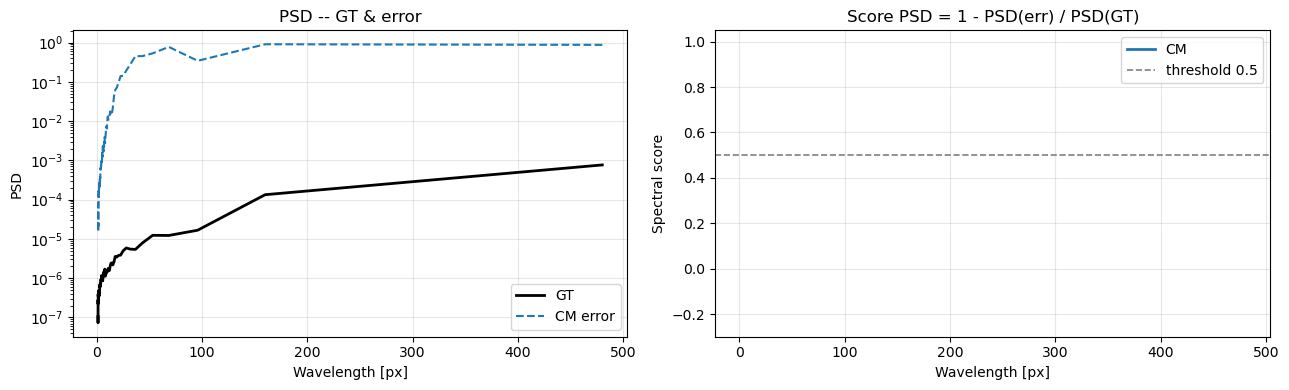

In [ ]:
import sys
sys.path.append('../..')
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale

T_EVAL = C // 2
DX = 1.0   # pixel spacing (px)

gt_n   = batch.asip[0, T_EVAL].float().cpu().numpy()
gt_p   = gt_n * s_norm + m_norm

mean_n = ens_mean[T_EVAL].float().cpu().numpy()
mean_p = mean_n * s_norm + m_norm

ens_n  = ensemble[:, T_EVAL].float().cpu().numpy()
ens_p  = ens_n * s_norm + m_norm

valid_t = valid_mask[0, T_EVAL].cpu().numpy()

gt_filled   = np.nan_to_num(gt_p, nan=0.0)
mean_filled = np.nan_to_num(mean_p, nan=0.0)

sigma_gt = float(np.nanstd(gt_p))
print(f't={T_EVAL} | sigma(GT)={sigma_gt:.4f} | valid coverage={valid_t.mean()*100:.1f}%')

def _metrics_row(pred_p, gt_p, label, valid, ens_p_arr=None, dx=DX):
    gt_v   = gt_p[valid]
    pred_v = pred_p[valid]
    sigma  = float(np.std(gt_v))
    rmse   = float(np.sqrt(np.mean((pred_v - gt_v) ** 2)))
    score  = 1.0 - rmse / sigma if sigma > 0 else np.nan
    sigma_pred = float(np.std(pred_v))
    gt_f   = np.nan_to_num(gt_p, nan=0.0)
    pred_f = np.nan_to_num(pred_p, nan=0.0)
    wl, _, _, spec = psd_spectral_score(pred_f, gt_f, dx=dx)
    lambda_x = resolved_scale(wl, spec, threshold=0.5)
    crps_val = np.nan
    if ens_p_arr is not None and HAS_PROPERSCORING:
        obs_ij = np.argwhere(valid)
        if len(obs_ij) > 0:
            crps_val = float(np.mean([
                crps_ensemble(float(gt_p[i, j]), ens_p_arr[:, i, j])
                for i, j in obs_ij[::10]
            ]))
    return {
        'Method'    : label,
        'Score'     : f'{score:.3f}',
        'RMSE'      : f'{rmse:.4f}',
        'sigma_GT'  : f'{sigma:.4f}',
        'sigma_pred': f'{sigma_pred:.4f}',
        'CRPS'      : f'{crps_val:.4f}' if not np.isnan(crps_val) else '--',
        'lambda_x'  : f'{lambda_x:.2f}' if not np.isnan(lambda_x) else '?',
    }, wl, spec

row_cm, wl_cm, spec_cm = _metrics_row(mean_p, gt_p, 'CM (ens. mean)',
                                       valid=valid_t, ens_p_arr=ens_p)

df_metrics = pd.DataFrame([row_cm]).set_index('Method')
df_metrics.columns = ['Score','RMSE','sigma_GT','sigma_pred','CRPS','lambda_x [px]']
print(f'\n## Metrics @ t={T_EVAL} -- pixel = {DX} px\n')
display(df_metrics)

_, psd_gt_r, psd_err_cm, _ = psd_spectral_score(mean_filled, gt_filled, dx=DX)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
valid_psd = np.isfinite(wl_cm) & np.isfinite(psd_gt_r) & (psd_gt_r > 0)
ax.semilogy(wl_cm[valid_psd], psd_gt_r[valid_psd],  'k-',   lw=2,   label='GT')
valid_err = np.isfinite(wl_cm) & np.isfinite(psd_err_cm) & (psd_err_cm > 0)
ax.semilogy(wl_cm[valid_err], psd_err_cm[valid_err], 'C0--', lw=1.5, label='CM error')
ax.set_xlabel('Wavelength [px]')
ax.set_ylabel('PSD')
ax.set_title('PSD -- GT & error')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
lambda_x_cm = resolved_scale(wl_cm, spec_cm)
lbl_cm = f'CM (lambda_x={lambda_x_cm:.2f} px)' if not np.isnan(lambda_x_cm) else 'CM'
valid_cm = np.isfinite(wl_cm) & np.isfinite(spec_cm)
ax.plot(wl_cm[valid_cm], spec_cm[valid_cm], 'C0-', lw=2, label=lbl_cm)
ax.axhline(0.5, color='gray', lw=1.2, ls='--', label='threshold 0.5')
if not np.isnan(lambda_x_cm):
    ax.axvline(lambda_x_cm, color='C0', lw=1, ls=':')
ax.set_xlabel('Wavelength [px]')
ax.set_ylabel('Spectral score')
ax.set_title('Score PSD = 1 - PSD(err) / PSD(GT)')
ax.set_ylim(-0.3, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Publication Figures -- comparison & uncertainty

  Saved: figures/CM_sic/CM_sic_asip_gt.png


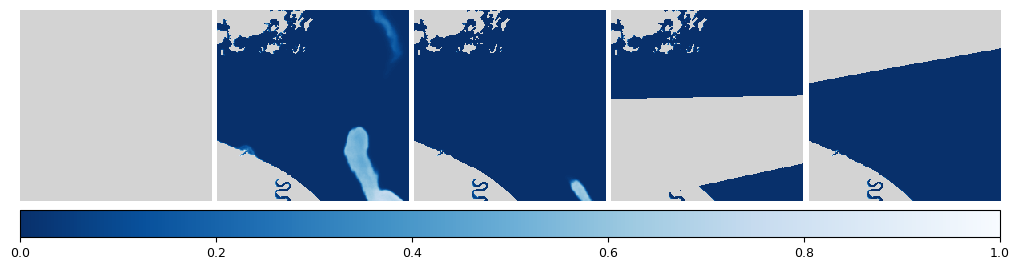

  Saved: figures/CM_sic/CM_sic_input.png


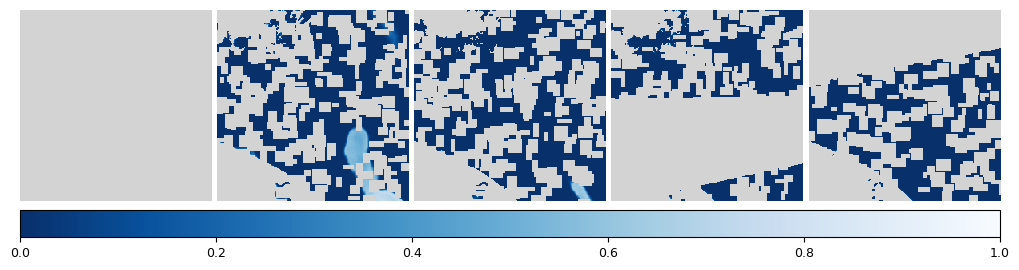

  Saved: figures/CM_sic/CM_sic_osisaf.png


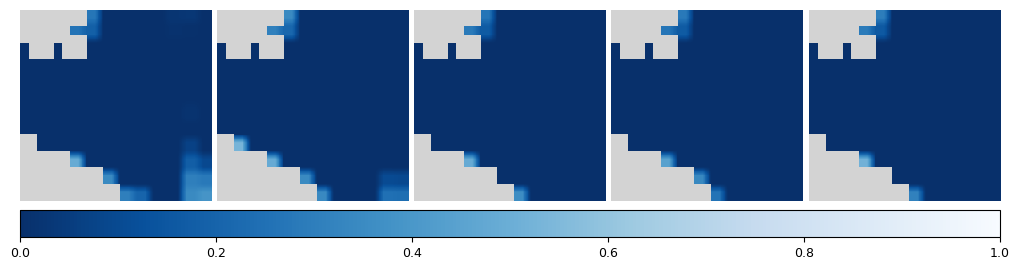

  Saved: figures/CM_sic/CM_sic_cm_mean.png


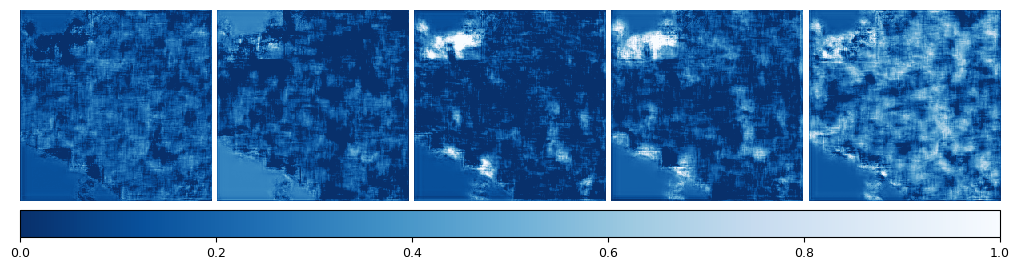

  Saved: figures/CM_sic/CM_sic_cm_spread.png


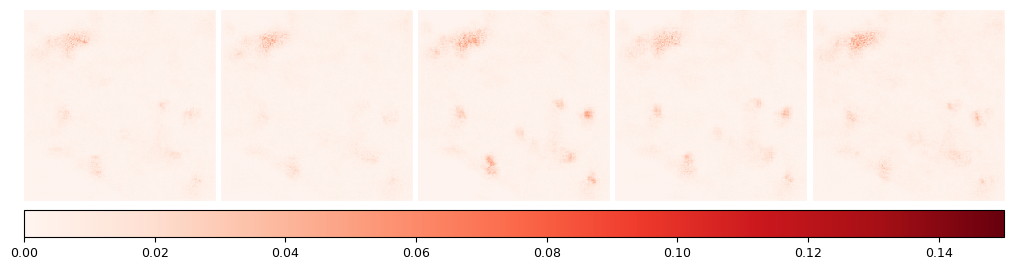

  Saved: figures/CM_sic/CM_sic_member0.png


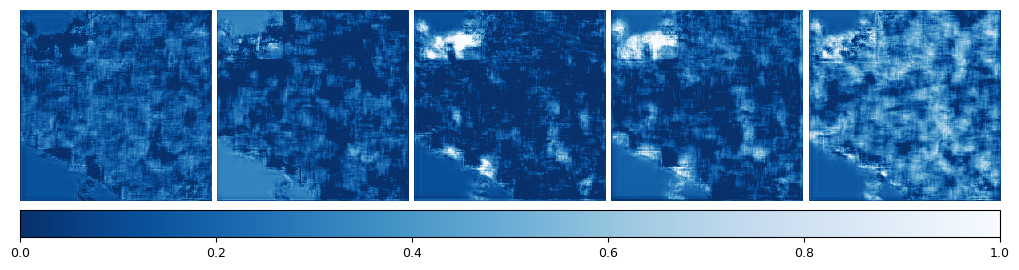

In [ ]:
from matplotlib.gridspec import GridSpec

FIG_TAG = 'CM_sic'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

N_SHOW = min(C, 5)

asip_phys  = batch.asip[0, :N_SHOW].float().cpu().numpy() * s_norm + m_norm
input_phys = batch.input[0, :N_SHOW].float().cpu().numpy() * s_norm + m_norm
osi_phys   = batch.osisaf[0, :N_SHOW].float().cpu().numpy() * s_norm + m_norm
mean_phys  = ens_mean[:N_SHOW].float().cpu().numpy() * s_norm + m_norm
std_phys   = ens_std[:N_SHOW].float().cpu().numpy() * s_norm
mbr0_phys  = ensemble[0, :N_SHOW].float().cpu().numpy() * s_norm + m_norm

SIC_MAX = float(s_norm)   # 1.0 (data already in [0,1])

cmap_sic = plt.cm.Blues_r.copy(); cmap_sic.set_bad('lightgray')
cmap_std = plt.cm.Reds.copy();   cmap_std.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap, ncols=None):
    nc = ncols or data.shape[0]
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig_w = nc * FW
    fig_h = FH + CB_H + 0.06
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = GridSpec(2, nc, left=0.01, right=0.99, top=0.99, bottom=0.01,
                  height_ratios=[FH, CB_H], hspace=0.06, wspace=0.03)
    for c in range(nc):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap,
                  vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}')
    plt.show()

for data, fname, vmin, vmax, cmap in [
    (asip_phys,  f'{FIG_TAG}_asip_gt',     0, SIC_MAX, cmap_sic),
    (input_phys, f'{FIG_TAG}_input',        0, SIC_MAX, cmap_sic),
    (osi_phys,   f'{FIG_TAG}_osisaf',       0, SIC_MAX, cmap_sic),
    (mean_phys,  f'{FIG_TAG}_cm_mean',      0, SIC_MAX, cmap_sic),
    (std_phys,   f'{FIG_TAG}_cm_spread',    0,  0.15,   cmap_std),
    (mbr0_phys,  f'{FIG_TAG}_member0',      0, SIC_MAX, cmap_sic),
]:
    _save_strip(data, fname, vmin, vmax, cmap)

### Transport Process -- denoising trajectory (member 0)

  Saved: figures/CM_sic/CM_sic_transport.png


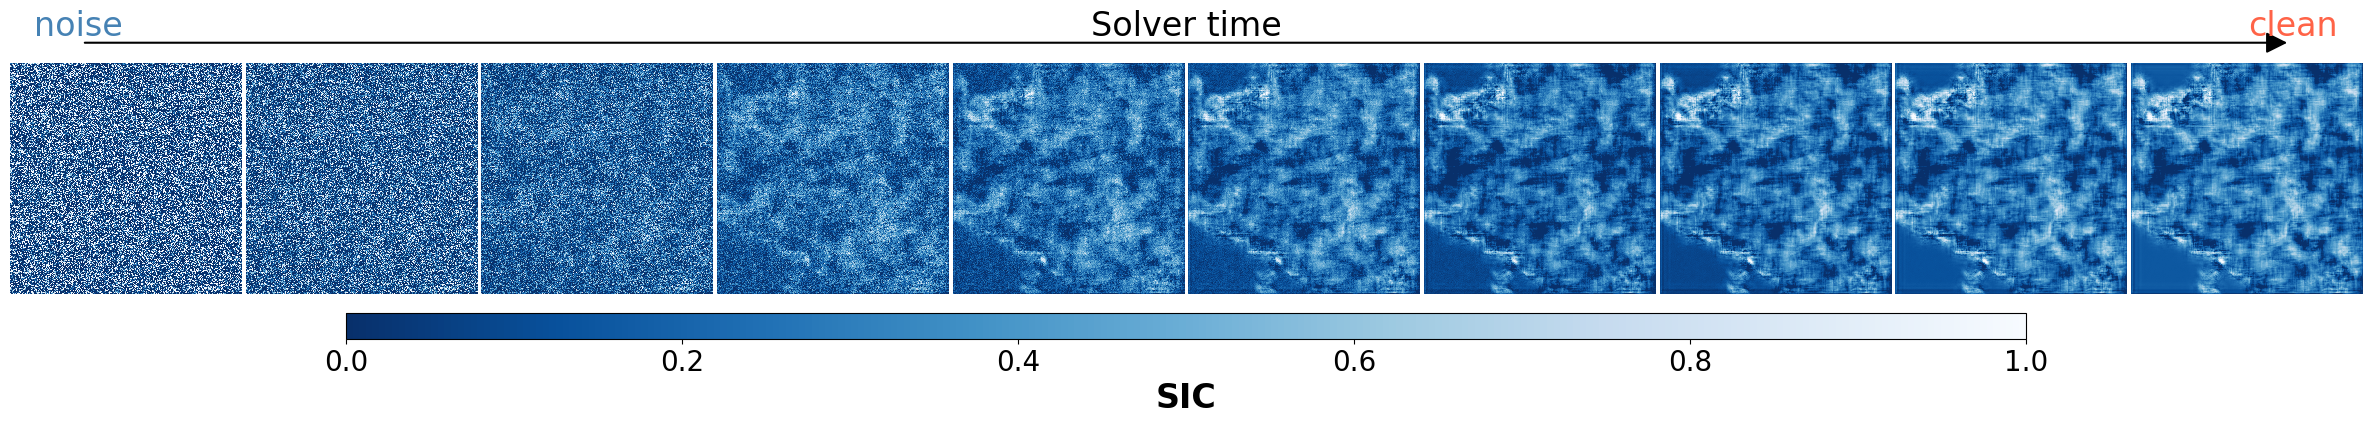

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

T_CH   = C // 2
N_SHOW = 10

proc = samples_process[0]
if proc.ndim == 5:
    transport_n = proc[:, 0, T_CH, :, :].float().cpu().numpy()
else:
    transport_n = proc[:, 0, 0, T_CH, :, :].float().cpu().numpy()
transport_p = transport_n * s_norm + m_norm

nfr = transport_p.shape[0]
stride = max(1, nfr // N_SHOW)
idx_show = list(range(0, nfr, stride))
if (nfr - 1) not in idx_show:
    idx_show.append(nfr - 1)
frames = transport_p[idx_show]
nf = len(frames)

SIC_MAX = float(s_norm)

FW, FH   = 2.4, 2.4
ARR_H    = 0.28
GAP_1    = 0.14
CB_H     = 0.26
GAP_2    = 0.16

fig_w = nf * FW
fig_h = ARR_H + GAP_1 + CB_H + GAP_2 + FH

arr_y_f   = (ARR_H / 2) / fig_h
cb_bot_f  = (ARR_H + GAP_1) / fig_h
cb_h_f    = CB_H / fig_h
img_bot_f = (ARR_H + GAP_1 + CB_H + GAP_2) / fig_h

fig = plt.figure(figsize=(fig_w, fig_h))
gs = GridSpec(1, nf, left=0.01, right=0.99, top=0.99, bottom=img_bot_f,
              hspace=0, wspace=0.02)

cmap_t = plt.cm.Blues_r
for i in range(nf):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(frames[i], origin='lower', cmap=cmap_t,
              vmin=0, vmax=SIC_MAX, interpolation='nearest')
    ax.axis('off')

cb_ax = fig.add_axes([0.15, cb_bot_f, 0.70, cb_h_f])
sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(0, SIC_MAX))
sm.set_array([])
cb = fig.colorbar(sm, cax=cb_ax, orientation='horizontal')
cb.set_label('SIC', fontsize=24, fontweight='bold')
cb.ax.tick_params(labelsize=20)

fig.add_artist(mpatches.FancyArrowPatch(
    (0.04, 1+arr_y_f), (0.96, 1+arr_y_f),
    transform=fig.transFigure, arrowstyle='-|>',
    color='black', mutation_scale=32, linewidth=1.5,
))
fig.text(0.02, 1+arr_y_f, 'noise', va='bottom', ha='left',  fontsize=24, color='steelblue')
fig.text(0.98, 1+arr_y_f, 'clean', va='bottom', ha='right', fontsize=24, color='tomato')
fig.text(0.50, 1+arr_y_f, 'Solver time', va='bottom', ha='center', fontsize=24)

fpath = os.path.join(FIG_DIR, f'{FIG_TAG}_transport.png')
fig.savefig(fpath, dpi=200, bbox_inches='tight')
print(f'  Saved: {fpath}')
plt.show()

In [ ]:
# --- metrics serialization (patch_notebook_params.py) ---
import os
os.makedirs(os.path.dirname(METRICS_CSV) or '.', exist_ok=True)
_df_out = df_metrics.reset_index() if df_metrics.index.name == 'Method' else df_metrics
_df_out.to_csv(METRICS_CSV, index=False)
print(f'Metrics written to {METRICS_CSV}')
